# Shifter - Electricity example




In [19]:
from __future__ import annotations

import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn.functional as F
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Каталог с pkl/выходами: по умолчанию cwd (запускайте ядро из shifter/experiments/example).
from pathlib import Path
try:
    SCRIPT_DIR = str(Path(__file__).resolve().parent)
except NameError:
    SCRIPT_DIR = str(Path.cwd().resolve())
EXP_DIR = os.path.dirname(SCRIPT_DIR)
PROJECT_ROOT = os.path.dirname(EXP_DIR)
WORKSPACE = os.path.dirname(PROJECT_ROOT)
# pickle CTGAN хранит классы из external.ctgan_repo — пакет лежит в latent-tabular-lens
CTGAN_LIB = os.path.join(WORKSPACE, "latent-tabular-lens")

for _p in (PROJECT_ROOT, WORKSPACE, CTGAN_LIB):
    if os.path.isdir(_p) and _p not in sys.path:
        sys.path.insert(0, _p)

from src.ctgan_adapter import CTGANRepoAdapter
from src.shifter import Shifter
from src.differentiable_mfe import extract_torch_mfe, get_attr_ent_boundaries, flatten_results

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TARGET_COL = "target"
SOURCE_CSV = os.path.join(WORKSPACE, "source", "electricity.csv")
TARGET_CSV = os.path.join(WORKSPACE, "target", "electricity.csv")
SOURCE_LABEL_COL = "class"

CTGAN_PKL_PATH = os.path.join(SCRIPT_DIR, "trained_ctgan_iris.pkl")
SYNTHETIC_CSV_PATH = os.path.join(SCRIPT_DIR, "synthetic_shifted.csv")
SHIFTER_WEIGHTS_PATH = os.path.join(SCRIPT_DIR, "shifter.pt")

META_FEATURES = ["mean"]
TRAIN_STEPS = 800
TRAIN_LR = 3e-4
TRAIN_N_SAMPLES = 200
TRAIN_ACCUM = 8
TRAIN_GRAD_CLIP = 1.0
DELTA_SCALE = 0.5
Z_LATENT_BOUND = 8.0

print("DEVICE:", DEVICE)
print("SCRIPT_DIR:", SCRIPT_DIR)

DEVICE: cpu
SCRIPT_DIR: /Users/nargiza/PycharmProjects/PythonProject6/shifter/experiments/example


In [20]:
def _drop_index_like_first_column(df: pd.DataFrame) -> pd.DataFrame:
    if df.shape[1] <= 1:
        return df
    first = df.columns[0]
    s = df[first]
    if str(first).lower().startswith("unnamed"):
        return df.drop(columns=[first])
    if pd.api.types.is_integer_dtype(s) or pd.api.types.is_float_dtype(s):
        v = s.to_numpy()
        if np.allclose(v, np.arange(len(v))) or np.allclose(v, np.arange(1, len(v) + 1)):
            return df.drop(columns=[first])
    return df


def load_dataset(path: str) -> pd.DataFrame:
    df = _drop_index_like_first_column(pd.read_csv(path))
    if SOURCE_LABEL_COL in df.columns:
        df[TARGET_COL] = pd.to_numeric(df[SOURCE_LABEL_COL], errors="coerce").fillna(0).astype(int)
        df = df.drop(columns=[SOURCE_LABEL_COL])
    elif TARGET_COL not in df.columns:
        df[TARGET_COL] = 0
    return df


def get_feature_col_indices(adapter: CTGANRepoAdapter, df: pd.DataFrame):
    indices, names = [], []
    for idx, ci in enumerate(adapter.m._transformer._column_transform_info_list):
        if ci.column_name != TARGET_COL and ci.column_name in df.columns:
            indices.append(idx)
            names.append(ci.column_name)
    return torch.tensor(indices, dtype=torch.long, device=DEVICE), names


def mx_from_df(df: pd.DataFrame, meta_features: list[str], feature_cols: list[str],
               attr_ent_boundaries: torch.Tensor | None = None) -> np.ndarray:
    sub = df.reindex(columns=feature_cols).apply(pd.to_numeric, errors="coerce").fillna(0.0)
    X = torch.tensor(sub.to_numpy(np.float64), dtype=torch.float32, device=DEVICE)
    y = (torch.tensor(df[TARGET_COL].values, dtype=torch.long, device=DEVICE)
         if TARGET_COL in df.columns else None)
    with torch.no_grad():
        res, _ = extract_torch_mfe(X, features=meta_features, y=y, cat_cols=[],
                                   attr_ent_boundaries=attr_ent_boundaries)
    parts = [res[mf].flatten().cpu().numpy() for mf in meta_features if mf in res]
    return np.concatenate(parts).astype(np.float64)


def load_ctgan() -> CTGANRepoAdapter:
    if not os.path.isfile(CTGAN_PKL_PATH):
        raise FileNotFoundError(
            f"Pre-trained CTGAN not found: {CTGAN_PKL_PATH}\n"
            "Place trained_ctgan_iris.pkl next to this notebook."
        )
    print("Loading CTGAN:", CTGAN_PKL_PATH)
    ctgan = torch.load(CTGAN_PKL_PATH, map_location=DEVICE, weights_only=False)
    ctgan.set_device(DEVICE)
    adapter = CTGANRepoAdapter(ctgan)
    adapter.m._generator.eval()
    for p in adapter.m._generator.parameters():
        p.requires_grad_(False)
    return adapter


def _z_for_ctgan(Z: torch.Tensor) -> torch.Tensor:
    return Z_LATENT_BOUND * torch.tanh(Z / Z_LATENT_BOUND)


def train_shifter(adapter: CTGANRepoAdapter, target_meta: torch.Tensor,
                  feat_idx: torch.Tensor, mx_scale: torch.Tensor,
                  attr_ent_boundaries: torch.Tensor | None) -> Shifter:
    z_dim = adapter.z_dim
    shifter = Shifter(z_dim=z_dim, m_dim=target_meta.shape[0],
                      c_dim=64, hidden_dim=256, delta_scale=DELTA_SCALE).to(DEVICE)
    opt = torch.optim.Adam(shifter.parameters(), lr=TRAIN_LR)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=TRAIN_STEPS, eta_min=1e-5)
    best = float("inf")
    for step in range(TRAIN_STEPS):
        opt.zero_grad()
        total = 0.0
        for _ in range(TRAIN_ACCUM):
            Z_base = torch.randn(TRAIN_N_SAMPLES, z_dim, device=DEVICE)
            cond_vec = adapter.sample_cond_vec(TRAIN_N_SAMPLES)
            Z_tilde = shifter(Z_base.unsqueeze(0), target_meta.unsqueeze(0))
            X_tilde = adapter.generate_from_noise_differentiable(
                _z_for_ctgan(Z_tilde).reshape(-1, z_dim), cond_vec=cond_vec,
            )[:, feat_idx]
            y = (torch.as_tensor(cond_vec, device=DEVICE).argmax(dim=1)
                 if cond_vec is not None and np.ndim(cond_vec) > 1 else None)
            res, _ = extract_torch_mfe(X_tilde, features=META_FEATURES, y=y, cat_cols=[],
                                       attr_ent_boundaries=attr_ent_boundaries)
            meta_tilde = torch.cat([res[mf].flatten() for mf in META_FEATURES if mf in res])
            loss = F.mse_loss(meta_tilde / mx_scale, target_meta / mx_scale)
            (loss / TRAIN_ACCUM).backward()
            total += loss.item()
        torch.nn.utils.clip_grad_norm_(shifter.parameters(), TRAIN_GRAD_CLIP)
        opt.step()
        sched.step()
        avg = total / TRAIN_ACCUM
        if avg < best:
            best = avg
            torch.save(shifter.state_dict(), SHIFTER_WEIGHTS_PATH)
        if step % 50 == 0 or step == TRAIN_STEPS - 1:
            print(f"step {step:4d}  loss={avg:.6f}  best={best:.6f}")
    shifter.load_state_dict(torch.load(SHIFTER_WEIGHTS_PATH, map_location=DEVICE))
    return shifter

In [21]:
# --- Pipeline (как в скрипте) ---
df_source = load_dataset(SOURCE_CSV)
df_target = load_dataset(TARGET_CSV)
print(f"source rows={len(df_source)}, target rows={len(df_target)}")

adapter = load_ctgan()
feat_idx, feature_cols = get_feature_col_indices(adapter, df_source)
print(f"z_dim={adapter.z_dim}, n_predictors={len(feature_cols)}")

X_source = torch.tensor(
    df_source[feature_cols].apply(pd.to_numeric, errors="coerce").fillna(0.0).to_numpy(np.float64),
    dtype=torch.float32, device=DEVICE,
)
needs_ent = any(mf in META_FEATURES for mf in ("attr_ent", "joint_ent"))
attr_ent_boundaries = get_attr_ent_boundaries(X_source).to(DEVICE) if needs_ent else None

target_vals = mx_from_df(df_target, META_FEATURES, feature_cols, attr_ent_boundaries)
src_vals = mx_from_df(df_source, META_FEATURES, feature_cols, attr_ent_boundaries)
target_meta = torch.tensor(target_vals, dtype=torch.float32, device=DEVICE)
mx_scale = torch.tensor(np.maximum(np.abs(src_vals), 1.0), dtype=torch.float32, device=DEVICE)

shifter = train_shifter(adapter, target_meta, feat_idx, mx_scale, attr_ent_boundaries)

shifter.eval()
n_rows = len(df_source)
with torch.no_grad():
    Z = torch.randn(1, n_rows, shifter.z_dim, device=DEVICE)
    Z_tilde = _z_for_ctgan(shifter(Z, target_meta.unsqueeze(0)))
    df_synth = adapter.generate_from_noise(Z_tilde.reshape(-1, shifter.z_dim).cpu().numpy())

# Базовая синтетика: обычный sample CTGAN (без Shifter), тот же размер
df_base = adapter.m.sample(n=n_rows)

df_synth.to_csv(SYNTHETIC_CSV_PATH, index=False)
print(f"Synthetic → {SYNTHETIC_CSV_PATH}")

source rows=9986, target rows=10014
Loading CTGAN: /Users/nargiza/PycharmProjects/PythonProject6/shifter/experiments/example/trained_ctgan_iris.pkl
z_dim=128, n_predictors=6
step    0  loss=0.001967  best=0.001967


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator BayesianGaussianMixture from version 1.7.2 when using version 1.7.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


step   50  loss=0.000088  best=0.000079
step  100  loss=0.000139  best=0.000053
step  150  loss=0.000122  best=0.000050
step  200  loss=0.000120  best=0.000050
step  250  loss=0.000103  best=0.000050
step  300  loss=0.000120  best=0.000050
step  350  loss=0.000105  best=0.000050
step  400  loss=0.000095  best=0.000048
step  450  loss=0.000134  best=0.000048
step  500  loss=0.000095  best=0.000045
step  550  loss=0.000191  best=0.000045
step  600  loss=0.000126  best=0.000045
step  650  loss=0.000207  best=0.000045
step  700  loss=0.000096  best=0.000043
step  750  loss=0.000077  best=0.000043
step  799  loss=0.000180  best=0.000043
Synthetic → /Users/nargiza/PycharmProjects/PythonProject6/shifter/experiments/example/synthetic_shifted.csv


## Визуализации

**Pairplot** — числовые предикторы CTGAN (`feature_cols`), три набора: source, shifted synthetic, target.

**Мета-характеристики (столбчатая диаграмма)** — те же `META_FEATURES`, что в обучении Shifter: **source → base synthetic (CTGAN без сдвига) → shifted → target** по каждому компоненту вектора MX.

**PCA** — `StandardScaler` и `PCA` **fit только на `df_source[feature_cols]`**; затем `transform` для source, shifted и target (одно и то же линейное подпространство).

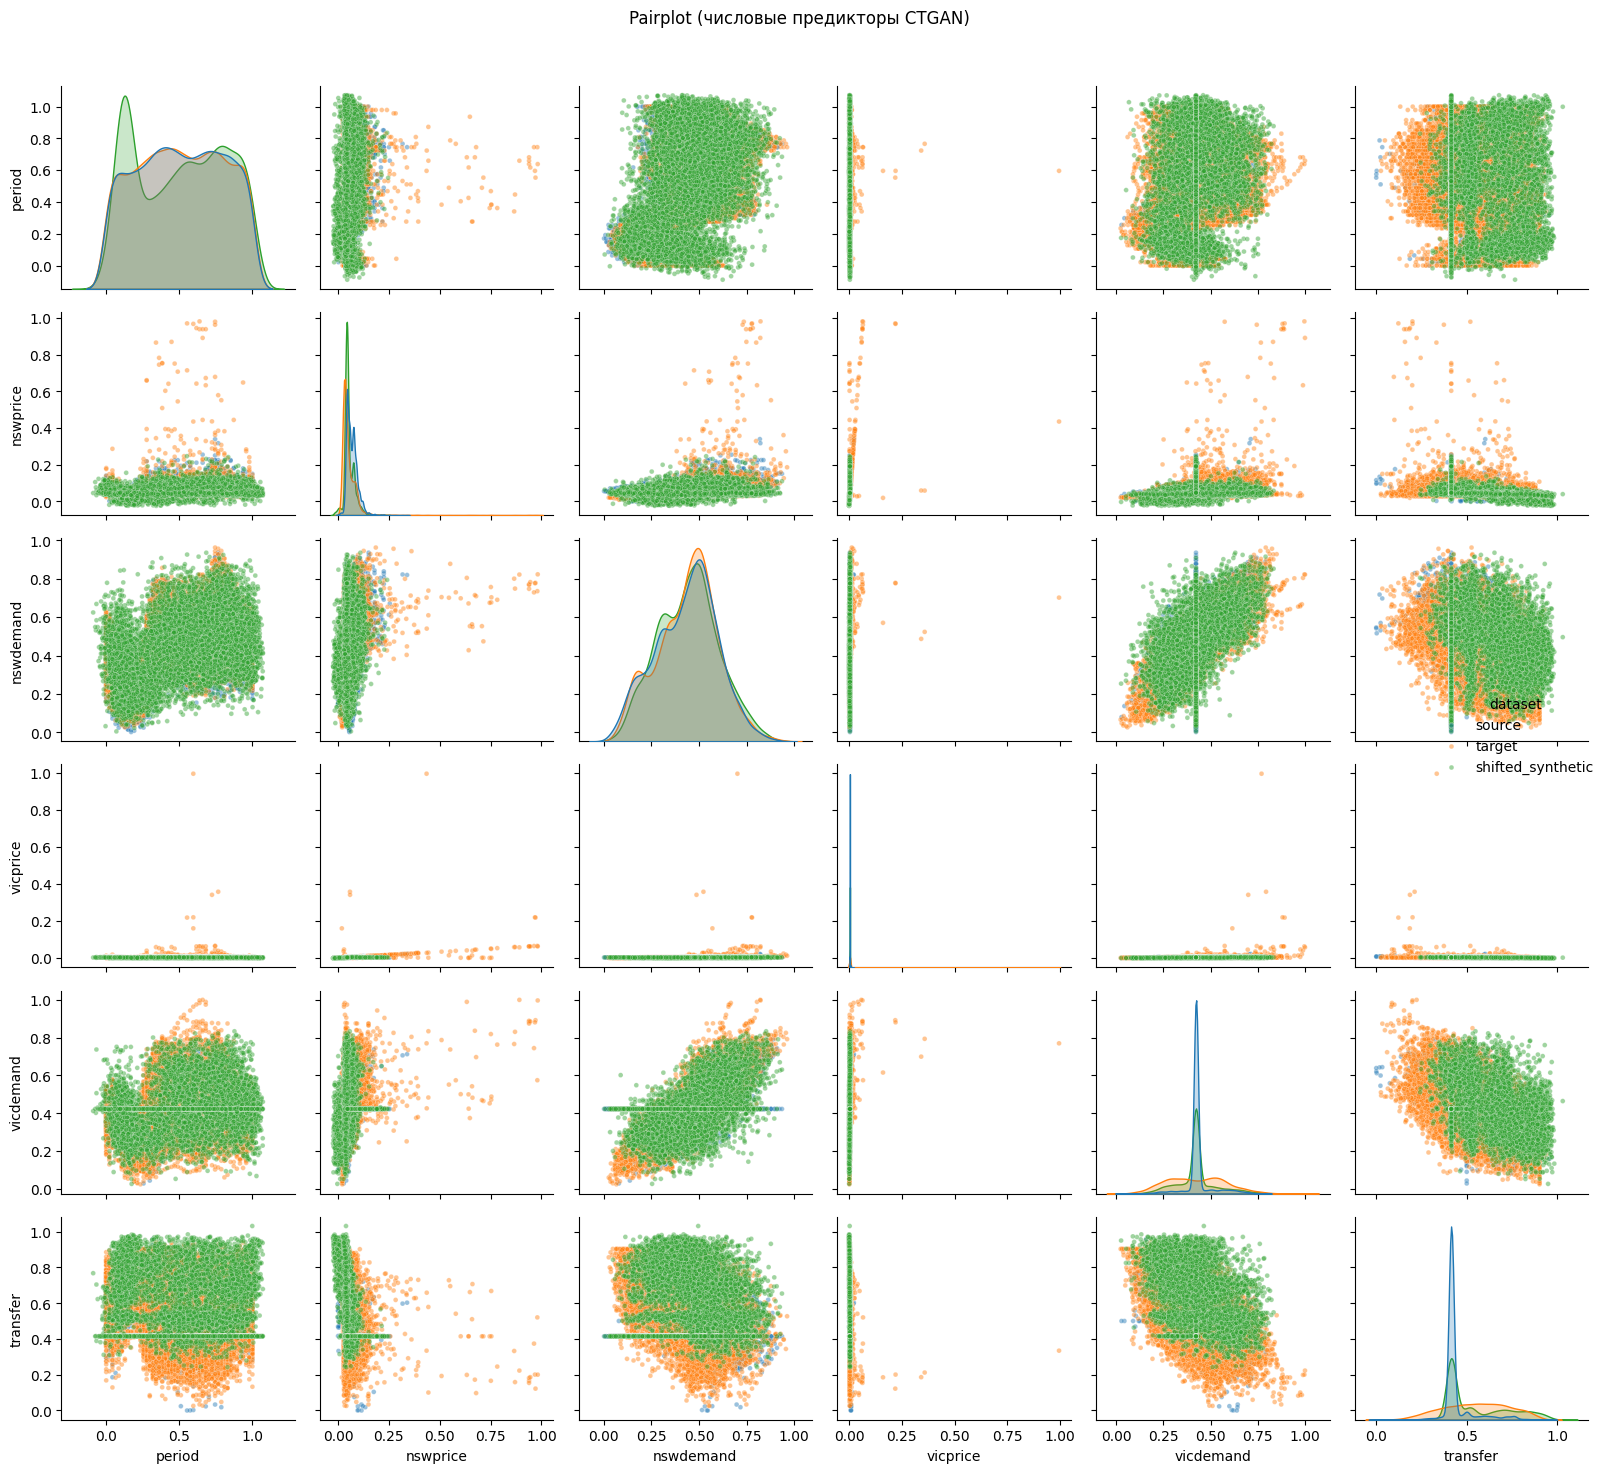

In [22]:
cols = [c for c in feature_cols if c in df_source.columns and c in df_synth.columns and c in df_target.columns]
if not cols:
    raise RuntimeError("Нет общих числовых колонок для визуализации")

# to_numeric + inf→nan; пропуски заливаем медианами source (эквивалент бывшего _align_numeric)
_src_num = df_source[cols].apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)
_fill = _src_num.median()
_fill = _fill.where(np.isfinite(_fill), 0.0).fillna(0.0)

ds = _src_num.fillna(_fill).assign(dataset="source")
dh = (
    df_synth.reindex(columns=cols)
    .apply(pd.to_numeric, errors="coerce")
    .replace([np.inf, -np.inf], np.nan)
    .fillna(_fill)
    .assign(dataset="shifted_synthetic")
)
dt = (
    df_target.reindex(columns=cols)
    .apply(pd.to_numeric, errors="coerce")
    .replace([np.inf, -np.inf], np.nan)
    .fillna(_fill)
    .assign(dataset="target")
)

MAX_PAIR = 8
pair_cols = cols[: min(len(cols), MAX_PAIR)]
combo = pd.concat([ds[pair_cols + ["dataset"]], dt[pair_cols + ["dataset"]], dh[pair_cols + ["dataset"]]], ignore_index=True)

h = max(1.6, min(2.4, 18.0 / max(len(pair_cols), 1)))
g = sns.pairplot(combo, hue="dataset", diag_kind="kde", plot_kws={"alpha": 0.45, "s": 12}, height=h)
g.fig.suptitle("Pairplot (числовые предикторы CTGAN)", y=1.02)
plt.tight_layout()
plt.show()


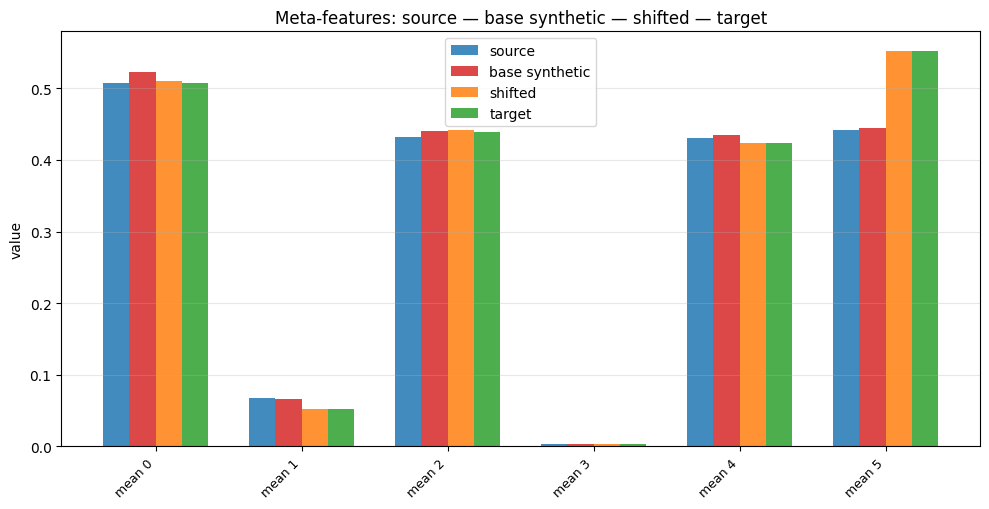

In [25]:


def _mx_vector(df: pd.DataFrame) -> tuple[np.ndarray, list[str]]:
    sub = df.reindex(columns=feature_cols).apply(pd.to_numeric, errors="coerce").fillna(0.0)
    X = torch.tensor(sub.to_numpy(np.float64), dtype=torch.float32, device=DEVICE)
    y = (torch.tensor(df[TARGET_COL].values, dtype=torch.long, device=DEVICE)
         if TARGET_COL in df.columns else None)
    with torch.no_grad():
        res, _ = extract_torch_mfe(
            X, features=META_FEATURES, y=y, cat_cols=[],
            attr_ent_boundaries=attr_ent_boundaries,
        )
    vec, labels = flatten_results(res)
    return vec.cpu().numpy().astype(np.float64), labels


v_src, mx_labels = _mx_vector(df_source)
v_base, lb2 = _mx_vector(df_base)
v_shift, lb3 = _mx_vector(df_synth)
v_tgt, lb4 = _mx_vector(df_target)
if mx_labels != lb2 or mx_labels != lb3 or mx_labels != lb4:
    raise RuntimeError(f"MX label mismatch: {mx_labels} vs {lb2}")

x = np.arange(len(mx_labels))
w = 0.18
fig_w = max(10.0, len(mx_labels) * 0.45)
fig, ax = plt.subplots(figsize=(fig_w, 5.2))
ax.bar(x - 1.5 * w, v_src, width=w, label="source", color="C0", alpha=0.85)
ax.bar(x - 0.5 * w, v_base, width=w, label="base synthetic", color="C3", alpha=0.85)
ax.bar(x + 0.5 * w, v_shift, width=w, label="shifted", color="C1", alpha=0.85)
ax.bar(x + 1.5 * w, v_tgt, width=w, label="target", color="C2", alpha=0.85)
ax.set_xticks(x)
short = [s.replace("_", " ") for s in mx_labels]
ax.set_xticklabels(short, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("value")
ax.set_title("Meta-features: source — base synthetic — shifted — target")
ax.legend(loc="best")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

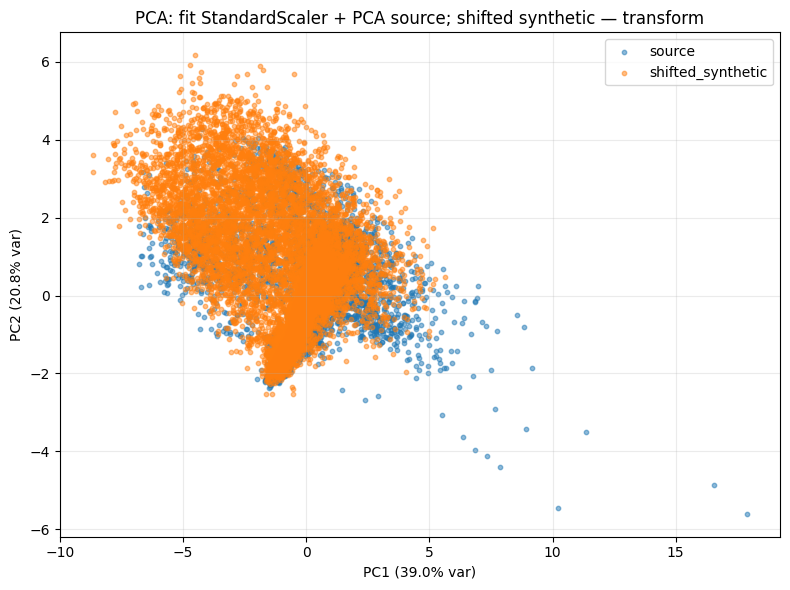

In [24]:
X_src = ds[cols].values.astype(np.float64)
scaler = StandardScaler().fit(X_src)
pca = PCA(n_components=2, random_state=42).fit(scaler.transform(X_src))

def embed(df_part: pd.DataFrame) -> np.ndarray:
    return pca.transform(scaler.transform(df_part[cols].values.astype(np.float64)))

P_src = embed(ds)
P_syn = embed(dh)

fig, ax = plt.subplots(figsize=(8, 6))
for P, label, color in [
    (P_src, "source", "C0"),
    (P_syn, "shifted_synthetic", "C1"),
]:
    ax.scatter(P[:, 0], P[:, 1], s=10, alpha=0.5, label=label, c=color)
ev = pca.explained_variance_ratio_
ax.set_xlabel(f"PC1 ({ev[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({ev[1]*100:.1f}% var)")
ax.set_title("PCA: fit StandardScaler + PCA source; shifted synthetic — transform")
ax.legend()
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()